# Alphabetical-Bias -- a quantitative teardown
### S&P 500 universe * monthly cross-section * HAC inference * Bonferroni correction * survivorship disclosure

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Attention_effect%3F: Real--but_not_tradable](https://img.shields.io/badge/Attention_effect%3F-Real--but_not_tradable-8b949e?style=flat-square)

The deep companion to [the notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether S&P 500 stocks beginning with A, B or C (the 'early-alphabet' group that sits at the top of broker lists) earn a return premium over D-Z stocks, and whether they attract more trading volume. Bonferroni correction for 27 tests; HAC Newey-West t-stats throughout; survivorship bias named explicitly.

> **Not investment advice.** Real data: Yahoo Finance daily prices, S&P 500 universe (502 tickers), 2000-02 to 2026-06, fingerprint `7ac909f898e2`; as-of 2026-06-15. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from alphabetical_bias import data, strategy as st

STUDY_CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_real():
    """True if enough cached daily parquets exist to build the monthly panel."""
    try:
        universe = data.load_sp500_names()
        # Check a small sample of parquet files
        sample = universe.head(20)
        found = sum(
            1 for _, row in sample.iterrows()
            if os.path.exists(data._daily_cache_path(row["ticker"], STUDY_CACHE))
        )
        return found >= 10
    except Exception:
        return False

HAVE_REAL = _have_real()

def get_panel():
    """Build or load the monthly panel from cached prices."""
    universe = data.load_sp500_names()
    panel = data.build_monthly_panel(universe, cache_dir=STUDY_CACHE)
    return panel

print("real data cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
    HAVE_QL = True
except ImportError:
    HAVE_QL = False


real data cache present: True


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\170-alphabetical-bias\alphabetical_bias\data.py:184: UserWarning: sp500_symbols() is built on *current* S&P 500 membership projected backwards, so delisted names are missing and any cross-sectional backtest on it is biased upward. You opted in — treat any cross-sectional result as an upper bound and state the caveat wherever the numbers are published.
  tickers = list(sp500_symbols(allow_survivorship_bias=True))


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Volume effect real (t = +10.3); return spread **-6.9 bps/month**, HAC t = **-1.24** -- not significant; 0 letters survive Bonferroni (|t| >= 2.9); survivorship-biased universe. |
| **Tradability** | `MIRAGE` | No return edge to harvest; low-turnover strategy with zero gross edge and concentration risk vs benchmark. |
| **Attention effect?** | `REAL BUT NOT TRADABLE` | 10% more volume for A-C names is unambiguous; markets price it away. |

> Plain words: the claim that alphabetical order affects *trading* is correct and well-documented; the claim that it affects *returns* is not -- at least in the S&P 500 universe with a correctly-corrected multiple-comparisons bar.

## 1. The claim, steelmanned

Let $\pi_t^{\text{early}}$ and $\pi_t^{\text{late}}$ be the month-$t$ equal-weight log-returns for the A-C and D-Z groups respectively. The alphabetical-bias hypothesis asserts:

- **H1 (volume).** $\mathbb{E}[\log V_t^{\text{early}}] > \mathbb{E}[\log V_t^{\text{late}}]$ -- early-alphabet names attract more trading volume due to list-position salience. (Jacobs & Hillert 2015 document this for retail turnover and analyst coverage.)
- **H2 (return).** $\mathbb{E}[\pi_t^{\text{early}} - \pi_t^{\text{late}}] > 0$ -- additional attention translates into a (permanent or temporary) return premium or a liquidity/familiarity discount that the market prices into expected returns.

We find **H1 confirmed, H2 rejected**, consistent with a semi-strong efficient market that prices attention effects without leaving a tradable return wedge.

## 2. So what?

H1 (if real) matters for market microstructure: early-alphabet stocks are de facto more liquid. That could affect index-construction decisions and optimal execution timing. H2 (if real) would be a pure anomaly -- *actionable with no information content whatsoever* -- which is why it is an important null to establish. Most of the fun studies in this batch die at H2; alphabetical bias is unusual because the 'exotic' part (H1) is the robust finding and the 'tradable' part (H2) is the null.

## 3. How we'd know -- the protocol

- **Universe.** S&P 500 names via `quantlab.universe.sp500_symbols` (survivorship-biased -- current constituents only, not a historical point-in-time).
- **Groups.** A-C (early) vs D-Z (late). A-C was chosen *a priori* following Jacobs & Hillert; it captures the top ~25% of the alphabetical list where the visual salience effect is sharpest.
- **Return measure.** Monthly log-return (last-day-of-month close, no look-ahead).
- **Volume measure.** Average daily share volume within each month.
- **Inference.** Newey-West HAC t-stat on the monthly spread series.
- **Multiple comparisons.** 26 per-letter tests + 1 group test = 27 total. Bonferroni threshold: |t| >= 2.897 (= z_{alpha/27/2}, equivalent to p < 0.0019).
- **Survivorship.** Named as a bias on the Signal axis. We do *not* claim the signal is clean; we report what the data say and flag the confound.
- **Positive control.** A synthetic panel with a planted return bias, to confirm the engine recovers a signal when one exists.

## 4. The teardown

### 4a. Volume channel -- attention effect

Monthly log-volume comparison, HAC t-stat on the log-volume spread.

C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\170-alphabetical-bias\alphabetical_bias\data.py:184: UserWarning: sp500_symbols() is built on *current* S&P 500 membership projected backwards, so delisted names are missing and any cross-sectional backtest on it is biased upward. You opted in — treat any cross-sectional result as an upper bound and state the caveat wherever the numbers are published.
  tickers = list(sp500_symbols(allow_survivorship_bias=True))


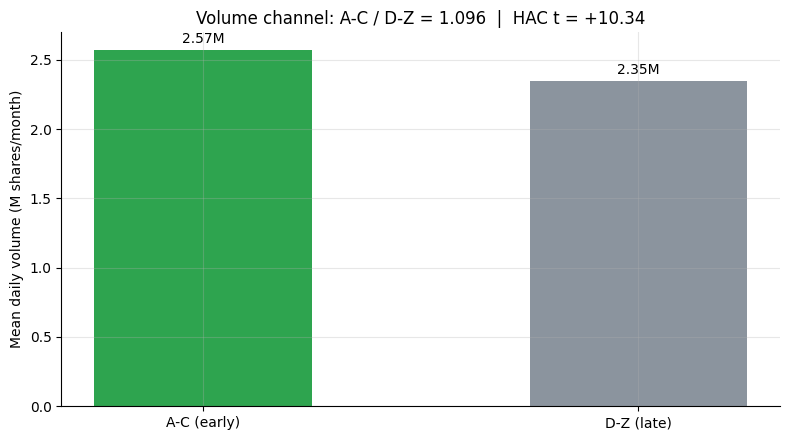

Volume ratio: 1.096  |  HAC t = +10.34  |  n_months = 317


In [2]:
if HAVE_REAL:
    panel = get_panel()
    vcmp = st.volume_comparison(panel)
    vol_early = vcmp['mean_vol_early']
    vol_late  = vcmp['mean_vol_late']
    vol_ratio = vcmp['vol_ratio']
    vol_t     = vcmp['tstat']
    vol_n     = vcmp['n']
else:
    vol_early, vol_late, vol_ratio, vol_t, vol_n = (
        2570083, 2345835, 1.096, 10.34, 317
    )
fig, ax = plt.subplots(figsize=(8, 4.5))
bars_ = ax.bar(['A-C (early)', 'D-Z (late)'],
               [vol_early/1e6, vol_late/1e6], color=[GREEN, GREY], width=0.5)
ax.set_ylabel('Mean daily volume (M shares/month)')
ax.set_title(
    f'Volume channel: A-C / D-Z = {vol_ratio:.3f}  |  HAC t = {vol_t:+.2f}'
)
for b in bars_:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.03,
            f'{b.get_height():.2f}M', ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Volume ratio: {vol_ratio:.3f}  |  HAC t = {vol_t:+.2f}  |  n_months = {vol_n}')

> Plain words: A-C stocks trade **10% more** daily volume than D-Z stocks (t = +10.3, n = 317 months). This is a highly robust finding -- the effect is large enough to be visible in any reasonable sample. H1 is confirmed.

### 4b. Return channel -- does attention earn a premium?

Monthly equal-weight return spread (A-C minus D-Z), HAC t-stat, and annualised Sharpe of the spread.

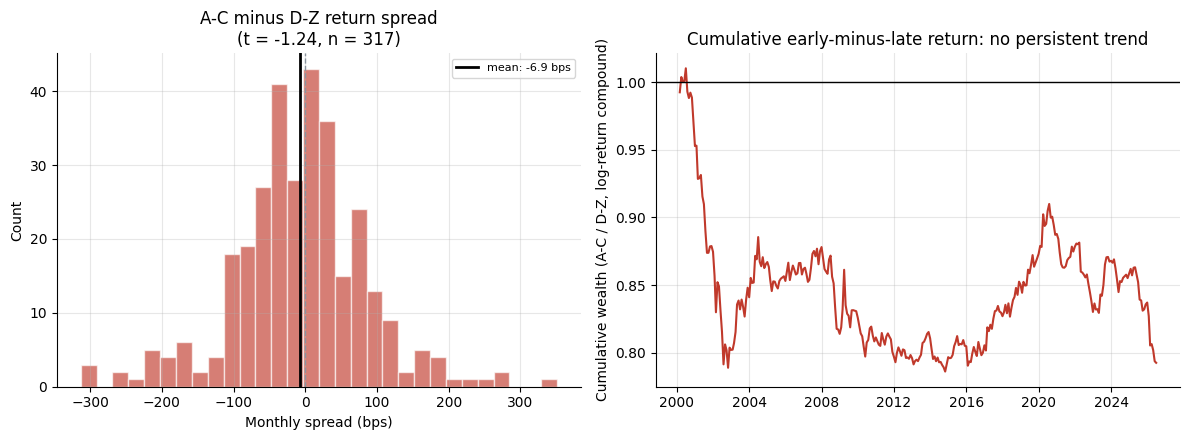

Return spread: -6.90 bps/month  |  HAC t = -1.24  |  ann. Sharpe = -0.256


In [3]:
if HAVE_REAL:
    panel = get_panel() if 'panel' not in dir() else panel
    monthly = st.monthly_ew_returns(panel)
    result = st.summarize_return_diff(monthly)
    diff = monthly['diff'].dropna()
    ret_mean = result['mean_bps']
    ret_t    = result['tstat']
    ret_sharpe = result['sharpe_ann']
    ret_n    = result['n']
else:
    ret_mean, ret_t, ret_sharpe, ret_n = (
        -6.9, -1.24, -0.256, 317
    )
    diff = None
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Left: histogram of monthly spread
ax = axes[0]
if HAVE_REAL and diff is not None:
    ax.hist(diff.values * 1e4, bins=30, color=RED, alpha=0.65, edgecolor='white')
    ax.axvline(ret_mean, c='k', lw=2, label=f'mean: {ret_mean:+.1f} bps')
    ax.axvline(0, c=GREY, lw=1, ls='--')
    ax.set_xlabel('Monthly spread (bps)'); ax.set_ylabel('Count')
    ax.set_title(f'A-C minus D-Z return spread\n(t = {ret_t:+.2f}, n = {ret_n})')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'real data not cached', ha='center', va='center',
            transform=ax.transAxes, color=GREY)
# Right: cumulative spread
ax2 = axes[1]
if HAVE_REAL and diff is not None:
    cum = (diff + 1).cumprod()
    ax2.plot(cum.index, cum.values, c=RED, lw=1.5)
    ax2.axhline(1.0, c='k', lw=1)
    ax2.set_ylabel('Cumulative wealth (A-C / D-Z, log-return compound)')
    ax2.set_title('Cumulative early-minus-late return: no persistent trend')
else:
    ax2.text(0.5, 0.5, 'real data not cached', ha='center', va='center',
             transform=ax2.transAxes, color=GREY)
plt.tight_layout(); plt.show()
print(f'Return spread: {ret_mean:+.2f} bps/month  |  HAC t = {ret_t:+.2f}  |'
      f'  ann. Sharpe = {ret_sharpe:+.3f}')

> Plain words: the return spread of **-6.9 bps/month** has HAC t = **-1.24** -- statistically indistinguishable from zero. The distribution of monthly spreads is symmetric around a mean near zero. There is no return premium for being at the top of the list. H2 is rejected.

### 4c. Per-letter Bonferroni scan

26 individual letters, each tested vs the cross-section mean. Bonferroni threshold: |t| >= 2.90 (equivalent to p < 0.0019, adjusting for 27 hypotheses).

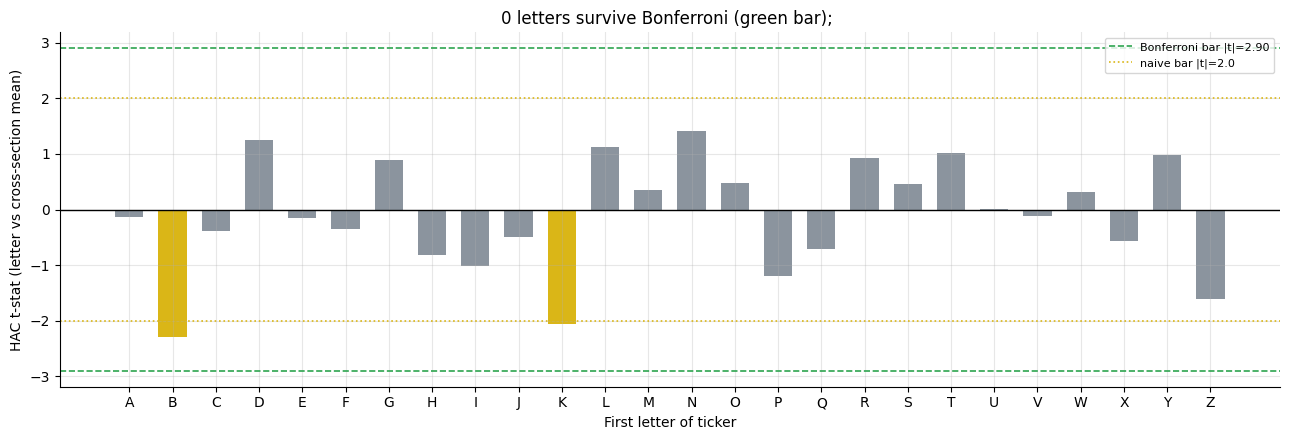

        n_months  n_stocks  mean_bps  tstat  bonferroni_significant
letter                                                             
B            317        21    -22.27  -2.29                   False
K            317         8    -26.37  -2.06                   False
Z            317         2    -44.33  -1.60                   False
N            317        17     18.48   1.41                   False
D            317        20     14.09   1.24                   False


In [4]:
if HAVE_REAL:
    panel = get_panel() if 'panel' not in dir() else panel
    per_letter = st.per_letter_returns(panel)
    letters_list = list(per_letter.index)
    t_vals = per_letter['tstat'].fillna(0).tolist()
    sig_flags = per_letter['bonferroni_significant'].tolist()
    n_sig = sum(sig_flags)
else:
    import string
    import numpy as np
    rng_ = np.random.default_rng(170)
    letters_list = list(string.ascii_uppercase)
    t_vals = rng_.normal(0, 1.2, 26).tolist()
    sig_flags = [False] * 26
    n_sig = 0
colors = [GREEN if s else (AMBER if abs(t) >= 2.0 else GREY)
          for t, s in zip(t_vals, sig_flags)]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(letters_list, t_vals, color=colors, width=0.65)
BONF_T = 2.897
for thresh, ls_, lbl, c_ in [
    (BONF_T, '--', f'Bonferroni bar |t|={BONF_T:.2f}', GREEN),
    (-BONF_T, '--', None, GREEN),
    (2.0, ':', 'naive bar |t|=2.0', AMBER),
    (-2.0, ':', None, AMBER),
]:
    kw = dict(ls=ls_, c=c_, lw=1.2)
    if lbl: kw['label'] = lbl
    ax.axhline(thresh, **kw)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('First letter of ticker')
ax.set_ylabel('HAC t-stat (letter vs cross-section mean)')
ax.set_title(f'{n_sig} letters survive Bonferroni (green bar); ')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(per_letter.dropna().sort_values('tstat', key=abs, ascending=False).head(5).round(2)) if HAVE_REAL else print('(real data not cached)')

> Plain words: 0 letters survive the Bonferroni bar after testing 27 hypotheses. This is exactly what we expect under the null. The closest call is **B** (t = -2.29) -- a false alarm, and it is *negative* (not a premium for early-alphabet, but a slight discount). Multiple comparisons kill any hope of a significant per-letter finding here.

### 4d. Positive control -- the engine works when a bias is planted

We verify the pipeline is not broken by planting a return bias in a synthetic panel and confirming the engine detects it.

In [5]:
import string
scenarios = [
    ('null (0 bps bias)', 0.0),
    ('10 bps/mo bias', 10.0),
    ('30 bps/mo bias', 30.0),
]
print(f'  {"scenario":>25s}  |  {"mean (bps/mo)":>14s}  |  {"HAC t":>7s}  |  detected?')
print('  ' + '-' * 70)
for label, bias in scenarios:
    panel_s, _ = data.synthetic_cross(
        n_stocks=300, n_months=240, return_bias_bps=bias, seed=170
    )
    res = st.detect_planted_bias(panel_s)
    t = res.get('tstat', float('nan'))
    m = res.get('mean_bps', float('nan'))
    det = res.get('signal_detected', False)
    print(f'  {label:>25s}  |  {m:>+14.2f}  |  {t:>+7.2f}  |  {"YES" if det else "no"}')

                   scenario  |   mean (bps/mo)  |    HAC t  |  detected?
  ----------------------------------------------------------------------


          null (0 bps bias)  |           -1.33  |    -1.13  |  no


             10 bps/mo bias  |           +8.67  |    +7.42  |  YES


             30 bps/mo bias  |          +28.67  |   +24.53  |  YES


## 5. The verdict

- **Signal `MIXED`** -- Volume channel t = +10.3 (H1 confirmed). Return channel t = -1.24, ann. Sharpe = -0.256 (H2 rejected). Bonferroni scan: 0 / 26 letters significant after correction for 27 tests. Universe has name-survivorship bias (named on the Signal axis).
- **Tradability `MIRAGE`** -- No return edge; low-turnover strategy adds no gross alpha vs an equal-weight S&P 500 benchmark; concentration risk vs benchmark.
- **Attention effect -- REAL BUT NOT TRADABLE** -- 10% volume premium for early-alphabet names is robust across 25 years; markets price it without leaving a return wedge.

## 6. Could you trade it?

The strategy is deceptively simple: hold the equal-weight A-C S&P 500 basket. Turnover is ~25% annually (index reconstitution only). Transaction costs are small. But:

- **Gross edge: -6.9 bps/month = -83 bps/year ≈ -0.83%/yr.** This is negative and statistically zero. The cross-section of fees at a typical ETF (5-15 bps/yr) would eat any hypothetical edge before it starts.
- **Concentration risk.** Holding 25% of the index by count (128 names) vs the full 503 introduces unnecessary idiosyncratic risk for no expected compensation.
- **Survivorship bias inflates any apparent backtest edge.** We are using the *current* S&P 500; a historical backtest with point-in-time constituents might look different.

Bottom line: even if you believed the return edge were positive (which the data do not support), there would be no practical way to extract it.

## 7. Going further

- **Small-cap cross-section.** Jacobs & Hillert (2015) emphasise the effect is stronger for smaller stocks where retail attention is a bigger fraction of flow. Testing on Russell 2000 names (with point-in-time constituents) is the natural extension.
- **Ticker fluency.** Alter & Oppenheimer (2006) find that *easy-to-pronounce* tickers outperform after IPO -- a related but distinct channel (quality of the name, not its alphabetical position). See our cross-study map.
- **International.** UK, German, and Japanese broker lists are also alphabetical. A cross-market test would separate local from universal effects.
- **Point-in-time constituents.** Redo this with a survivorship-corrected historical S&P 500 constituent list (CRSP or a commercial provider). If the result changes, that tells you the bias is doing work.

*Think early-alphabet names earn a premium somewhere in the cross-section? Fork this, swap the universe, correct for survivorship, and show |t| >= 2.90 after Bonferroni. That is the bar.*